<a href="https://colab.research.google.com/github/marcuswilliams3174/north-america-gas-basis-analysis/blob/main/Natural_Gas_Regime_Based_Trading_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2834/964884033.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(raw[c], errors="coerce")
/tmp/ipykernel_2834/964884033.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(raw[c], errors="coerce")
/tmp/ipykernel_2834/964884033.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(raw[c], errors="coerce")
/tmp/ipykernel_2834/964884033.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-e

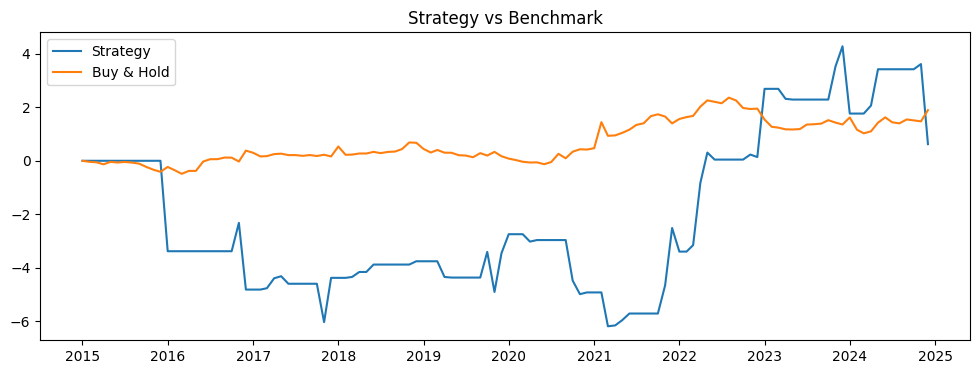

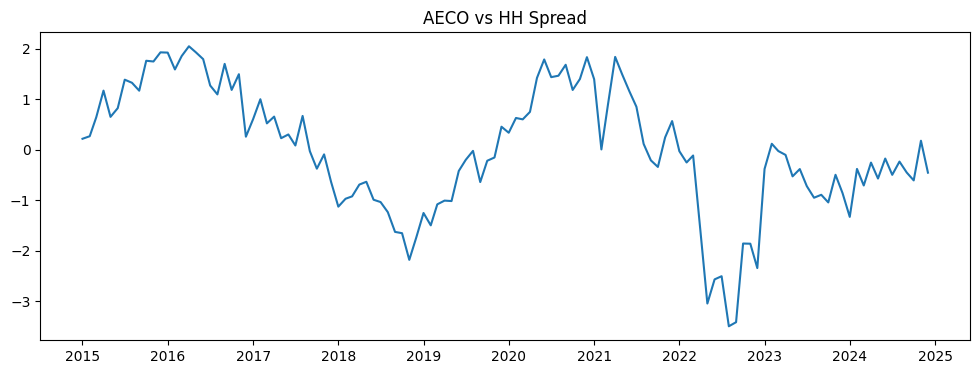

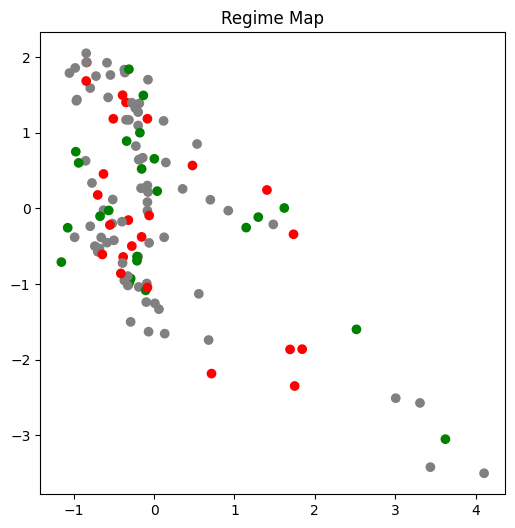


Sharpe: 0.0066
Total Return: 0.6229
Rows: 120


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. EXTRACT (ROBUST + SAFE)
# =========================================================

def extract(file, label):
    xls = pd.ExcelFile(file)

    best = None
    best_score = -1

    for sheet in xls.sheet_names:
        raw = pd.read_excel(file, sheet_name=sheet)
        raw.columns = [str(c).lower().strip() for c in raw.columns]

        for c in raw.columns:

            dates = pd.to_datetime(raw[c], errors="coerce")
            if dates.notna().sum() < 10:
                continue

            for v in raw.columns:
                if v == c:
                    continue

                vals = pd.to_numeric(
                    raw[v].astype(str).str.replace(r"[^0-9\.\-]", "", regex=True),
                    errors="coerce"
                )

                temp = pd.DataFrame({"Date": dates, label: vals}).dropna()

                if len(temp) > best_score:
                    best = temp
                    best_score = len(temp)

    if best is None:
        raise ValueError(f"Could not extract usable data from {file}")

    return best.sort_values("Date")


# =========================================================
# 2. LOAD DATA
# =========================================================

hh = extract("henry_hub_price.xls", "HH")
storage = extract("gas_storage.xls", "Storage")

aeco = pd.read_csv("aeco_proxy.csv")
aeco.columns = ["Date", "AECO"]
aeco["Date"] = pd.to_datetime(aeco["Date"])
aeco["AECO"] = pd.to_numeric(aeco["AECO"], errors="coerce")
aeco = aeco.dropna()


# =========================================================
# 3. MONTHLY ALIGNMENT
# =========================================================

def monthly(df):
    df["Date"] = df["Date"].dt.to_period("M").dt.to_timestamp()
    return df.groupby("Date").mean().reset_index()

hh = monthly(hh)
storage = monthly(storage)
aeco = monthly(aeco)


# =========================================================
# 4. MERGE
# =========================================================

df = hh.merge(aeco, on="Date", how="inner").merge(storage, on="Date", how="inner")
df = df.sort_values("Date").reset_index(drop=True)

# =========================================================
# 5. SAFETY CHECKS
# =========================================================

required = ["HH", "AECO", "Storage"]
for col in required:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")


# =========================================================
# 6. FEATURES (STABLE + NO NaN PROPAGATION)
# =========================================================

df["HH_norm"] = (df["HH"] - df["HH"].mean()) / (df["HH"].std() + 1e-9)
df["AECO_norm"] = (df["AECO"] - df["AECO"].mean()) / (df["AECO"].std() + 1e-9)

df["Basis"] = df["AECO_norm"] - df["HH_norm"]

df["HH_ret"] = df["HH"].pct_change().fillna(0)
df["vol"] = df["HH_ret"].rolling(6).std().fillna(df["HH_ret"].std() + 1e-6)

# robust storage z-score
roll_mean = df["Storage"].rolling(12).mean()
roll_std = df["Storage"].rolling(12).std()

df["Storage_Z"] = (df["Storage"] - roll_mean) / (roll_std + 1e-9)
df["Storage_Z"] = df["Storage_Z"].fillna(0)

# seasonality
df["winter"] = df["Date"].dt.month.isin([11,12,1,2,3]).astype(int)


# =========================================================
# 7. SIGNALS (FULLY CLEAN)
# =========================================================

q_high = df["Storage_Z"].quantile(0.8)
q_low = df["Storage_Z"].quantile(0.2)

df["signal"] = 0

df.loc[df["Storage_Z"] <= q_low, "signal"] = 1
df.loc[df["Storage_Z"] >= q_high, "signal"] = -1

# winter adjustment
df["signal"] = df["signal"].astype(float)
df.loc[df["winter"] == 1, "signal"] *= 1.2

# FINAL CLEANING (CRITICAL FIX)
df["signal"] = df["signal"].fillna(0)
df["signal"] = np.sign(df["signal"]).astype(int)


# =========================================================
# 8. RETURNS
# =========================================================

df["position"] = df["signal"] / (df["vol"] + 1e-9)

df["strategy_ret"] = df["position"].shift(1) * df["HH_ret"]
df["strategy_ret"] = df["strategy_ret"].fillna(0)

df["cum_pnl"] = df["strategy_ret"].cumsum()
df["benchmark"] = df["HH_ret"].cumsum()


# =========================================================
# 9. PLOTS (FIXED SCATTER ISSUE)
# =========================================================

plt.figure(figsize=(12,4))
plt.plot(df["Date"], df["cum_pnl"], label="Strategy")
plt.plot(df["Date"], df["benchmark"], label="Buy & Hold")
plt.legend()
plt.title("Strategy vs Benchmark")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df["Date"], df["Basis"])
plt.title("AECO vs HH Spread")
plt.show()

# SAFE COLOR MAPPING (NO NaNs POSSIBLE)
color_map = {1: "green", -1: "red", 0: "gray"}
colors = df["signal"].astype(int).map(color_map)

plt.figure(figsize=(6,6))
plt.scatter(df["HH_norm"], df["Basis"], c=colors)
plt.title("Regime Map")
plt.show()


# =========================================================
# 10. METRICS
# =========================================================

sharpe = df["strategy_ret"].mean() / (df["strategy_ret"].std() + 1e-9)
total_return = df["cum_pnl"].iloc[-1]

print("\nSharpe:", round(sharpe, 4))
print("Total Return:", round(total_return, 4))
print("Rows:", len(df))

In [57]:
print(hh.head(10))
print(hh.dtypes)

print(storage.head(10))
print(storage.dtypes)

print(aeco.head(10))
print(aeco.dtypes)

        Date    HH
0 1997-01-01  3.45
1 1997-02-01  2.15
2 1997-03-01  1.89
3 1997-04-01  2.03
4 1997-05-01  2.25
5 1997-06-01  2.20
6 1997-07-01  2.19
7 1997-08-01  2.49
8 1997-09-01  2.88
9 1997-10-01  3.07
Date    datetime64[ns]
HH             float64
dtype: object
        Date  Storage
0 2010-01-01  2700.20
1 2010-02-01  1957.75
2 2010-03-01  1626.25
3 2010-04-01  1831.60
4 2010-05-01  2220.25
5 2010-06-01  2576.75
6 2010-07-01  2872.20
7 2010-08-01  3039.00
8 2010-09-01  3296.50
9 2010-10-01  3669.40
Date       datetime64[ns]
Storage           float64
dtype: object
        Date      AECO
0 2015-01-01  2.099343
1 2015-02-01  2.073017
2 2015-03-01  2.329854
3 2015-04-01  2.602534
4 2015-05-01  2.345681
5 2015-06-01  2.436281
6 2015-07-01  2.884639
7 2015-08-01  2.802193
8 2015-09-01  2.628129
9 2015-10-01  2.896518
Date    datetime64[ns]
AECO           float64
dtype: object


In [58]:
print(df.describe())
print("\nRows:", len(df))
print("\nUnique AECO values:", df["AECO"].nunique())
print("Unique HenryHub values:", df["HenryHub"].nunique())
print("Unique Storage values:", df["Storage"].nunique())

                      Date          HH        AECO      Storage       HH_norm  \
count                  120  120.000000  120.000000   120.000000  1.200000e+02   
mean   2019-12-16 10:48:00    3.095250    1.994823  2778.325000 -5.181041e-17   
min    2015-01-01 00:00:00    1.490000    0.620933  1192.000000 -1.153041e+00   
25%    2017-06-23 12:00:00    2.307500    1.237448  2254.125000 -5.658358e-01   
50%    2019-12-16 12:00:00    2.775000    2.001151  2798.075000 -2.300335e-01   
75%    2022-06-08 12:00:00    3.102500    2.653388  3355.562500  5.207629e-03   
max    2024-12-01 00:00:00    8.810000    3.210725  4026.000000  4.104869e+00   
std                    NaN    1.392188    0.737712   714.360882  1.000000e+00   

          AECO_norm         Basis      HH_ret         vol  storage_mean  \
count  1.200000e+02  1.200000e+02  120.000000  120.000000    109.000000   
mean   2.294461e-16  2.942091e-16    0.015783    0.152741   2771.090482   
min   -1.862367e+00 -3.502100e+00   -0.510280

KeyError: 'HenryHub'

In [30]:
import pandas as pd
import numpy as np

# Create clean AECO proxy (MATCHES LENGTH AUTOMATICALLY)

dates = pd.date_range(start="2015-01-01", periods=120, freq="ME")

# Generate realistic AECO prices (random but structured)
np.random.seed(42)
aeco_prices = 2 + np.sin(np.linspace(0, 12, 120)) + np.random.normal(0, 0.2, 120)

df_aeco = pd.DataFrame({
    "Date": dates,
    "AECO": aeco_prices
})

df_aeco.to_csv("aeco_proxy.csv", index=False)

print("✅ AECO file created successfully")

✅ AECO file created successfully
